In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import types
import os
import sys

sys.path.append('../..')

from src import Multicolour_Simulation_Functions
from src import sCMOSFunctions
from src import SpectralFunctions
from src import MaskFunctions
from src import PlottingBase
from src import IOFunctions

IO = IOFunctions.IO_Functions()


MSF   = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()
sCMOS = sCMOSFunctions.sCMOS_Functions()
S_F   = SpectralFunctions.Spectral_Funcs()
M_F   = MaskFunctions.Mask_Functions()

plotter = PlottingBase.PublicationPlotter(dark_background=True)

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20260219_132633.log


In [2]:
# data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = "../../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

In [3]:
# ---------------------------------------------------------------------------
# Simulation parameters
# ---------------------------------------------------------------------------
image_size        = 100     # pixels (square FOV)
n_molecules       = 16      # 10 at E~0.3, 10 at E~0.8
n_photons_per_mol = 2000    # photons per frame per molecule
background_per_px = 3.0     # photons per pixel (background)
pixel_size        = 69      # nm per pixel
NA                = 1.49

E_low   = 0.3
E_high  = 0.8
E_sigma = 0.05   # Gaussian spread around each E value

rng = np.random.default_rng(42)

print(f"FOV: {image_size * pixel_size / 1000:.2f} × {image_size * pixel_size / 1000:.2f} µm²")
print(f"Signal: {n_photons_per_mol} ph/mol  |  Background: {background_per_px} ph/px")

FOV: 6.90 × 6.90 µm²
Signal: 2000 ph/mol  |  Background: 3.0 ph/px


/tmp/ipykernel_62190/998319004.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


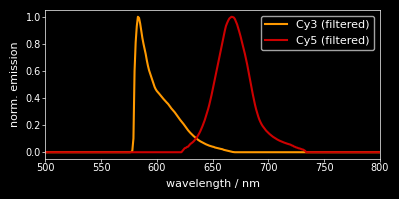

In [4]:
# ---------------------------------------------------------------------------
# Dye spectra + filters (568 LP dichroic, same as DNA HJ experiment)
# ---------------------------------------------------------------------------
cy3_spec = np.squeeze(S_F.get_dye_or_filter_data(['Cy3'], wavelength=wavelength))
cy5_spec = np.squeeze(S_F.get_dye_or_filter_data(['Cy5'], wavelength=wavelength))

# Apply the longpass filter (568 LP) to dye spectra
dichroic_mirror = "semrock-di03-r488-561-t1-25x36"
longpass_filter = "semrock-blp01-568r"
filters = [dichroic_mirror, longpass_filter]

# Check filter transmission at each wavelength and apply
filter_transmission = np.ones_like(wavelength)
for filt_name in filters:
    filt_data = np.squeeze(S_F.get_dye_or_filter_data([filt_name], wavelength=wavelength, dye_or_filter=False))
    filter_transmission = filter_transmission* (filt_data / np.max(filt_data))

cy3_filtered = cy3_spec * filter_transmission
cy5_filtered = cy5_spec * filter_transmission

# Normalise
cy3_filtered = cy3_filtered / cy3_filtered.sum()
cy5_filtered = cy5_filtered / cy5_filtered.sum()

fig, ax = plt.subplots(1, 1, figsize=(4, 2))
ax.plot(wavelength, cy3_filtered / cy3_filtered.max(), color='#ff9900', label='Cy3 (filtered)')
ax.plot(wavelength, cy5_filtered / cy5_filtered.max(), color='#cc0000', label='Cy5 (filtered)')
ax.set_xlim([500, 800])
ax.set_xlabel('wavelength / nm')
ax.set_ylabel('norm. emission')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [5]:
# ---------------------------------------------------------------------------
# Sample per-molecule FRET efficiencies and compute spectral fractions
# ---------------------------------------------------------------------------
n_per_group = n_molecules // 2

E_low_vals  = np.clip(rng.normal(E_low,  E_sigma, n_per_group), 0.01, 0.99)
E_high_vals = np.clip(rng.normal(E_high, E_sigma, n_per_group), 0.01, 0.99)
E_vals = np.concatenate([E_low_vals, E_high_vals])

# Per-molecule pixel fractions [B, G, R] and average emission wavelength
mol_pe  = np.zeros((n_molecules, 3))
mol_awl = np.zeros(n_molecules)

for i, E in enumerate(E_vals):
    spec = cy3_filtered * (1.0 - E) + cy5_filtered * E
    spec /= spec.sum()
    _, pe = S_F.get_pixel_fractions_rawspectra(
        spectra=spec, wavelength=wavelength, pixel_QYs=pixel_QYs
    )
    mol_pe[i]  = pe / pe.sum()
    mol_awl[i] = np.trapz(wavelength * spec, wavelength)

print("Group      | n  | E (mean ± std)       | B      G      R")
print("-" * 65)
for grp, idx, label in [(0, slice(None, n_per_group),  f"E~{E_low}"),
                         (1, slice(n_per_group, None),  f"E~{E_high}")]:
    E_g = E_vals[idx]
    pe_g = mol_pe[idx].mean(axis=0)
    print(f"  {label:<10} | {n_per_group:2d} | {E_g.mean():.3f} ± {E_g.std():.3f}      "
          f"| {pe_g[0]:.3f}  {pe_g[1]:.3f}  {pe_g[2]:.3f}")

Group      | n  | E (mean ± std)       | B      G      R
-----------------------------------------------------------------
  E~0.3      |  8 | 0.284 ± 0.048      | 0.030  0.344  0.627
  E~0.8      |  8 | 0.810 ± 0.035      | 0.050  0.235  0.715


In [6]:
# ---------------------------------------------------------------------------
# Flat synthetic camera calibration
# ---------------------------------------------------------------------------
masks = M_F.get_masks(size_x=image_size, size_y=image_size)

camera_params = {
    "gain":                np.full((image_size, image_size), np.median(gain_map)),
    "offset":              np.full((image_size, image_size), np.median(offset_map)),
    "variance":            np.full((image_size, image_size), np.median(variance)),
    "readnoise":           np.full((image_size, image_size), np.median(read_noise)),
    "rqe":                 np.full((image_size, image_size), 1.0),
    "pixel_QYs":           pixel_QYs,
    "pixel_order":         ["B", "G", "R"],
    "pixel_order_indices": [0, 1, 2],
    "masks":               masks,
}

smoothing_fn = types.SimpleNamespace()
smoothing_fn.args               = {"sigma": 1.5}
smoothing_fn.extent             = 1.5
smoothing_fn.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_fn.data_arg           = "image"

print("Camera calibration ready (flat: gain={}, offset={}, variance={})".format(np.median(gain_map), np.median(offset_map), np.median(variance)))

Camera calibration ready (flat: gain=0.4143771529197693, offset=32.34640121459961, variance=0.9374151229858398)


In [7]:
# ---------------------------------------------------------------------------
# Random molecule positions with minimum separation (rejection sampling)
# ---------------------------------------------------------------------------
margin_px       = 8
min_sep_px      = 6   # minimum centre-to-centre separation in pixels
max_attempts    = 100_000

def place_molecules(n, image_size, margin, min_sep, rng, max_attempts=100_000):
    """Place n molecules with rejection sampling to enforce min_sep_px."""
    positions = []
    attempts  = 0
    while len(positions) < n:
        if attempts >= max_attempts:
            raise RuntimeError(
                f"Could not place {n} molecules with min_sep={min_sep} px "
                f"after {max_attempts} attempts. Reduce n_molecules or min_sep_px."
            )
        candidate = rng.uniform(margin, image_size - margin, size=2)
        if len(positions) == 0:
            positions.append(candidate)
        else:
            dists = np.linalg.norm(np.array(positions) - candidate, axis=1)
            if dists.min() >= min_sep:
                positions.append(candidate)
        attempts += 1
    return np.array(positions)   # (n, 2)  [x, y] in pixels

pos_px = place_molecules(n_molecules, image_size, margin_px, min_sep_px, rng)

print(f"Placed {n_molecules} molecules (min separation: {min_sep_px} px = {min_sep_px*pixel_size/1000:.2f} µm):")
for i, (x, y) in enumerate(pos_px):
    grp = 'low' if i < n_per_group else 'high'
    print(f"  mol {i:02d} [{grp:4s}] E={E_vals[i]:.3f}  pos=({x*pixel_size/1000:.2f}, {y*pixel_size/1000:.2f}) µm")

# Verify no pair is closer than min_sep_px
from scipy.spatial.distance import cdist
D = cdist(pos_px, pos_px)
np.fill_diagonal(D, np.inf)
print(f"\nClosest pair: {D.min():.2f} px  (min_sep_px = {min_sep_px})")

Placed 16 molecules (min separation: 6 px = 0.41 µm):
  mol 00 [low ] E=0.315  pos=(3.77, 0.92) µm
  mol 01 [low ] E=0.248  pos=(5.35, 4.21) µm
  mol 02 [low ] E=0.338  pos=(4.95, 2.61) µm
  mol 03 [low ] E=0.347  pos=(6.18, 5.73) µm
  mol 04 [low ] E=0.202  pos=(5.06, 1.68) µm
  mol 05 [low ] E=0.235  pos=(3.26, 0.81) µm
  mol 06 [low ] E=0.306  pos=(1.45, 4.51) µm
  mol 07 [low ] E=0.284  pos=(4.87, 6.16) µm
  mol 08 [high] E=0.799  pos=(2.44, 2.70) µm
  mol 09 [high] E=0.757  pos=(3.27, 1.65) µm
  mol 10 [high] E=0.844  pos=(1.31, 3.31) µm
  mol 11 [high] E=0.839  pos=(1.87, 4.43) µm
  mol 12 [high] E=0.803  pos=(3.09, 5.38) µm
  mol 13 [high] E=0.856  pos=(4.61, 2.36) µm
  mol 14 [high] E=0.823  pos=(5.38, 5.22) µm
  mol 15 [high] E=0.757  pos=(2.80, 2.22) µm

Closest pair: 6.01 px  (min_sep_px = 6)


In [8]:

# ---------------------------------------------------------------------------
# Build x0y0 / n_photons dicts and simulate all molecules in a single call.
#
# gen_camera_image_stack iterates over x0y0.keys() in insertion order and
# maps the j-th key to dye_pixel_efficiency[j, :].  One key per molecule
# gives each molecule its own [B, G, R] spectral profile.
#
# Background note: the function splits background_photons equally across
# len(dye_names) entries, but the maths always yields
#   total photoelectrons/pixel = background_photons / 3  (uniform background)
# So set background_photons = 3 * background_per_px to get the target level.
# ---------------------------------------------------------------------------

x0y0      = {}
n_photons = {}
for i in range(n_molecules):
    key = f"mol_{i:02d}"
    entry = np.zeros((1, 2, 1))          # (n_frames=1, xy=2, n_mol=1)
    entry[0, 0, 0] = pos_px[i, 0] * pixel_size   # x in nm
    entry[0, 1, 0] = pos_px[i, 1] * pixel_size   # y in nm
    x0y0[key]      = entry
    n_photons[key] = np.array([n_photons_per_mol])

# dye_pixel_efficiency rows must be in the same insertion order as x0y0 keys
dye_pixel_efficiency = mol_pe   # (n_molecules, 3) — [B, G, R] per molecule

# Scalar avg wavelength for PSF sigma (mean across all molecules; the spread
# between E=0.3 and E=0.8 is ~15 nm in sigma, negligible for a figure)
avg_emission_wl = float(np.mean(mol_awl))

bayer_image, smoothed_image, _ = MSF.gen_camera_image_stack(
    camera_params,
    wavelength,
    avg_emission_wl,
    dye_pixel_efficiency,
    n_photons,
    x0y0,
    smoothing_function=smoothing_fn,
    background_photons=3.0 * background_per_px,   # ×3 because total pe/px = arg/3
    NA=NA,
    pixel_size=pixel_size,
)

bayer_frame    = bayer_image[0]     # (100, 100)
smoothed_frame = smoothed_image[0]

print(f"Simulation complete  ({n_molecules} molecules, single call).")
print(f"  avg emission wavelength: {avg_emission_wl:.1f} nm")
print(f"  Bayer image: min={bayer_frame.min():.0f}  max={bayer_frame.max():.0f} ADU")
print(f"  Expected background: {background_per_px:.1f} pe/px  "
      f"(background_photons arg = {3.0*background_per_px:.1f})")


Simulation complete  (16 molecules, single call).
  avg emission wavelength: 638.6 nm
  Bayer image: min=30  max=35 ADU
  Expected background: 3.0 pe/px  (background_photons arg = 9.0)


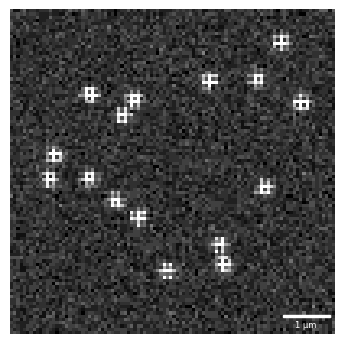

In [20]:
# ---------------------------------------------------------------------------
# Display: raw Bayer image (left) + demosaiced RGB with E-coloured markers (right)
# ---------------------------------------------------------------------------

fig, axs = plotter.one_column_plot()

# --- left: raw Bayer image ---
vmax_bayer = np.percentile(bayer_image, 99.5)
axs = plotter.image_plot(axs, bayer_image, scalebar_color='white', scalebarsize=1000, scalebar=True, scalebarlabel='1 µm')

folder='/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Conference Presentations/20260302_DurhamTalks/Research/fig/multicolour_camera/FRET/'
plt.savefig(os.path.join(folder, 'FRET_exemplar_image.svg'))
plt.show()


In [96]:
# ============================================================
# Single-molecule time series — 14×14 crop, 1000 frames
# ============================================================

# --- configurable -------------------------------------------
mol_idx         = 12   # which molecule to zoom in on
crop_size       = 14   # pixels (14×14 crop centred on molecule)

n_ts_low        = 400  # frames in low-E state
n_ts_high       = 400  # frames in high-E state
n_ts_bleach     = 200  # bleached frames (no photons)
n_ts_total      = n_ts_low + n_ts_high + n_ts_bleach

E_ts_low_val    = 0.3
E_ts_high_val   = 0.8
E_ts_sigma_low  = 0.1
E_ts_sigma_high = 0.1   # wide spread; clipped to [0.01, 0.99]
# ------------------------------------------------------------

# Per-frame FRET efficiencies (np.nan = bleached)
E_ts = np.concatenate([
    np.clip(rng.normal(E_ts_low_val,  E_ts_sigma_low,  n_ts_low),  0.01, 0.99),
    np.clip(rng.normal(E_ts_high_val, E_ts_sigma_high, n_ts_high), 0.01, 0.99),
    np.full(n_ts_bleach, np.nan),
])

# Per-frame [B, G, R] pixel efficiencies and average emission wavelengths
pe_ts  = np.zeros((n_ts_total, 3))
awl_ts = np.zeros(n_ts_total)
_awl_fallback = float(np.mean(mol_awl))
for f, E in enumerate(E_ts):
    if np.isnan(E):
        pe_ts[f]  = [1/3, 1/3, 1/3]   # placeholder — n_photons=0 so ignored
        awl_ts[f] = _awl_fallback
    else:
        spec = cy3_filtered * (1 - E) + cy5_filtered * E
        spec /= spec.sum()
        _, pe = S_F.get_pixel_fractions_rawspectra(
            spectra=spec, wavelength=wavelength, pixel_QYs=pixel_QYs
        )
        pe_ts[f]  = pe / pe.sum()
        awl_ts[f] = np.trapz(wavelength * spec, wavelength)

# Photon counts per frame (0 for bleached)
n_photons_ts = np.full(n_ts_total, float(n_photons_per_mol))
n_photons_ts[n_ts_low + n_ts_high:] = 0.0

# 14×14 camera calibration (flat, median values from loaded maps)
mol_centre_px  = np.array([crop_size / 2.0, crop_size / 2.0])   # pixel coords in crop
masks_crop     = M_F.get_masks(size_x=crop_size, size_y=crop_size)
camera_params_crop = {
    "gain":                np.full((crop_size, crop_size), np.median(gain_map)),
    "offset":              np.full((crop_size, crop_size), np.median(offset_map)),
    "variance":            np.full((crop_size, crop_size), np.median(variance)),
    "readnoise":           np.full((crop_size, crop_size), np.median(read_noise)),
    "rqe":                 np.full((crop_size, crop_size), 1.0),
    "pixel_QYs":           pixel_QYs,
    "pixel_order":         ["B", "G", "R"],
    "pixel_order_indices": [0, 1, 2],
    "masks":               masks_crop,
}

# x0y0: shape (n_ts_total, 2, 1) — molecule fixed at crop centre every frame
x0y0_ts = {"mol": np.zeros((n_ts_total, 2, 1))}
x0y0_ts["mol"][:, 0, 0] = mol_centre_px[0] * pixel_size   # x in nm
x0y0_ts["mol"][:, 1, 0] = mol_centre_px[1] * pixel_size   # y in nm
n_photons_dict_ts = {"mol": n_photons_ts}

# pe_ts shape (n_ts_total, 3) → shape[0] == s == n_ts_total triggers
# stochastic spectral mode: dye_pixel_efficiency[frame, channel] used per frame.
# awl_ts shape (n_ts_total,) → ndim > 0 triggers per-frame PSF sigma.
bayer_ts, smoothed_ts, _ = MSF.gen_camera_image_stack(
    camera_params_crop,
    wavelength,
    awl_ts,            # per-frame emission wavelength → per-frame PSF sigma
    pe_ts,             # (n_ts_total, 3)   → stochastic spectral mode
    n_photons_dict_ts,
    x0y0_ts,
    smoothing_function=smoothing_fn,
    background_photons=3.0 * background_per_px,
    NA=NA,
    pixel_size=pixel_size,
)

print(f"Time series shape: {bayer_ts.shape}  ({n_ts_total} frames × {crop_size}×{crop_size} px)")
print(f"  Frames   0–{n_ts_low-1:3d}: E ~ N({E_ts_low_val}, {E_ts_sigma_low:.2f})  (low FRET)")
print(f"  Frames {n_ts_low:3d}–{n_ts_low+n_ts_high-1}: E ~ N({E_ts_high_val}, {E_ts_sigma_high:.2f})  (high FRET, clipped)")
print(f"  Frames {n_ts_low+n_ts_high:3d}–{n_ts_total-1}: bleached (0 photons)")
print(f"  ADU range: {bayer_ts.min():.0f} – {bayer_ts.max():.0f}")

Time series shape: (1000, 14, 14)  (1000 frames × 14×14 px)
  Frames   0–399: E ~ N(0.3, 0.10)  (low FRET)
  Frames 400–799: E ~ N(0.8, 0.10)  (high FRET, clipped)
  Frames 800–999: bleached (0 photons)
  ADU range: 28 – 95


PSF sigma: 1.31 px  |  aperture: r≤4.57 px  |  bg annulus: 5.07–6.50 px
Aperture pixels: 68  |  BG annulus pixels: 44

Results: 1000 frames  |  200 bleached
 frame   E_true       A_B      A_G      A_R  total_signal
     0 0.262390  0.049714 0.488747 0.461538    653.116036
     1 0.254192  0.006202 0.563298 0.430500    601.340630
     2 0.376897 -0.041351 0.493453 0.547898    636.661988
  ...
 frame   E_true      A_B      A_G      A_R  total_signal
   398 0.233541 0.061628 0.522302 0.416071    644.340544
   399 0.195474 0.061550 0.515017 0.423433    591.687588
   400 0.743228 0.037119 0.443211 0.519670    691.508816
   401 0.737918 0.048732 0.435816 0.515452    553.733583


/tmp/ipykernel_62190/853058853.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  R[-200:] = np.NAN
/tmp/ipykernel_62190/853058853.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  G[-200:] = np.NAN
/tmp/ipykernel_62190/853058853.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  B[-200:] = np.NAN


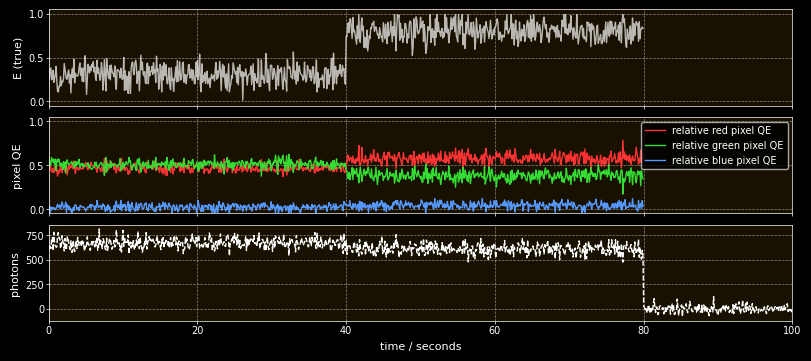

In [97]:
# ============================================================
# Aperture photometry: extract per-frame A_R, A_G, A_B
# ============================================================
import pandas as pd

# Pixel coordinate grid (centres at +0.5 within each pixel)
yy, xx = np.mgrid[0:crop_size, 0:crop_size].astype(float) + 0.5
cx, cy = mol_centre_px[0], mol_centre_px[1]
r_grid = np.sqrt((xx - cx)**2 + (yy - cy)**2)

# PSF sigma in pixels  (σ ≈ 0.21 λ / NA, diffraction limit)
_lambda_nm  = float(np.nanmean(awl_ts))
sigma_ap_px = 0.21 * _lambda_nm / NA / pixel_size

aperture_r  = 3.5 * sigma_ap_px                             # captures >99.9% of Gaussian PSF
bg_r_inner  = aperture_r + 0.5                              # 0.5 px gap
bg_r_outer  = min(crop_size / 2.0 - 0.5, bg_r_inner + 2.0) # outer edge of bg annulus

ap_mask = r_grid <= aperture_r
bg_mask = (r_grid > bg_r_inner) & (r_grid <= bg_r_outer)

print(f"PSF sigma: {sigma_ap_px:.2f} px  |  aperture: r≤{aperture_r:.2f} px  "
      f"|  bg annulus: {bg_r_inner:.2f}–{bg_r_outer:.2f} px")
print(f"Aperture pixels: {ap_mask.sum()}  |  BG annulus pixels: {bg_mask.sum()}")

# Bayer masks per channel
ch_masks  = {c: masks_crop[c].astype(bool) for c in ("B", "G", "R")}
gain_crop = camera_params_crop["gain"]
off_crop  = camera_params_crop["offset"]

# Per-frame aperture photometry
rows = []
for f in range(n_ts_total):
    pe_frame = (bayer_ts[f].astype(float) - off_crop) / gain_crop
    sigs = {}
    for ch in ("B", "G", "R"):
        ap_ch  = ap_mask & ch_masks[ch]
        bg_ch  = bg_mask & ch_masks[ch]
        bg_lev = pe_frame[bg_ch].mean() if bg_ch.sum() > 0 else 0.0
        sigs[ch] = pe_frame[ap_ch].sum() - bg_lev * ap_ch.sum()
    total = sum(sigs.values())
    rows.append({
        "frame":        f,
        "E_true":       E_ts[f],
        "A_B":          sigs["B"] / total if total > 0 else np.nan,
        "A_G":          sigs["G"] / total if total > 0 else np.nan,
        "A_R":          sigs["R"] / total if total > 0 else np.nan,
        "sig_B":        sigs["B"],
        "sig_G":        sigs["G"],
        "sig_R":        sigs["R"],
        "total_signal": total,
    })

df_ts = pd.DataFrame(rows)
df_ts["bleached"] = df_ts["E_true"].isna()

print(f"\nResults: {len(df_ts)} frames  |  {df_ts['bleached'].sum()} bleached")
print(df_ts[["frame","E_true","A_B","A_G","A_R","total_signal"]].head(3).to_string(index=False))
print("  ...")
print(df_ts[["frame","E_true","A_B","A_G","A_R","total_signal"]].iloc[398:402].to_string(index=False))

# --- Plot traces -----------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(8, 3.5), sharex=True)
frames = df_ts["frame"].values/10

shade_kw = dict(zorder=0, lw=0)
for ax in axs:
    ax.axvspan(0,                      n_ts_low,             alpha=0.10, color='#ffaa00', **shade_kw)
    ax.axvspan(n_ts_low,               n_ts_low + n_ts_high, alpha=0.10, color='#cc0000', **shade_kw)
    ax.axvspan(n_ts_low + n_ts_high,   n_ts_total,           alpha=0.10, color='#888888', **shade_kw)

axs[0].plot(frames, df_ts["E_true"],       color='white',   lw=1, alpha=0.7)
axs[0].set_ylabel("E (true)")
axs[0].set_ylim(-0.05, 1.05)

R = df_ts['A_R']
R[-200:] = np.NAN

G = df_ts['A_G']
G[-200:] = np.NAN

B = df_ts['A_B']
B[-200:] = np.NAN

axs[1].plot(frames, R, color='#ff3333', lw=1, label='relative red pixel QE')
axs[1].plot(frames, G, color='#33dd33', lw=1, label='relative green pixel QE')
axs[1].plot(frames, B, color='#5599ff', lw=1, label='relative blue pixel QE')
axs[1].set_ylabel("pixel QE")
axs[1].set_ylim(-0.05, 1.05)
axs[1].legend(fontsize=7, loc='upper right')

axs[2].plot(frames, df_ts["total_signal"], color='white', ls='--', lw=1)
axs[2].set_ylabel("photons")
axs[2].set_xlabel("time / seconds")

for i in np.arange(3):
    axs[i].set_xlim([0, 1000/10])
    axs[i].grid(True, ls='--', color='white', alpha=0.5, lw=0.5, zorder=-1)

folder='/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Conference Presentations/20260302_DurhamTalks/Research/fig/multicolour_camera/FRET/'
plt.savefig(os.path.join(folder, 'exemplar_trace.svg'))

plt.show()

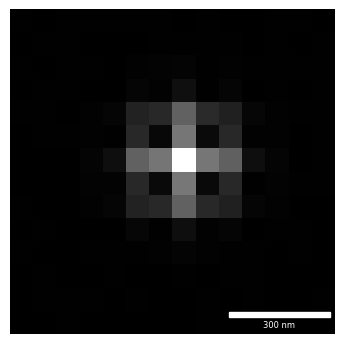

In [98]:
fig, axs = plotter.one_column_plot()

mean_frame = np.mean(bayer_ts[:400], axis=0)

# --- left: raw Bayer image ---
axs = plotter.image_plot(axs, mean_frame, scalebar_color='white', scalebarsize=300, scalebar=True, scalebarlabel='300 nm',
                        vmax=np.percentile(mean_frame, 99.9), vmin=np.percentile(mean_frame, 0.1))

folder='/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Conference Presentations/20260302_DurhamTalks/Research/fig/multicolour_camera/FRET/'
plt.savefig(os.path.join(folder, 'FRET_exemplar_image_firstNframes.svg'))
plt.show()

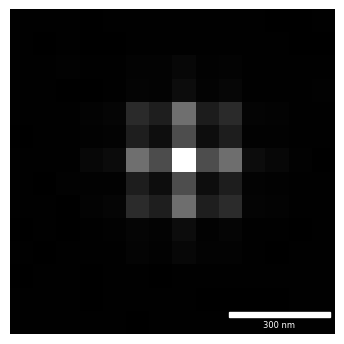

In [99]:
fig, axs = plotter.one_column_plot()

mean_frame = np.mean(bayer_ts[400:800], axis=0)

# --- left: raw Bayer image ---
axs = plotter.image_plot(axs, mean_frame, scalebar_color='white', scalebarsize=300, scalebar=True, scalebarlabel='300 nm',
                                                vmax=np.percentile(mean_frame, 99.9), vmin=np.percentile(mean_frame, 0.1))

folder='/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Conference Presentations/20260302_DurhamTalks/Research/fig/multicolour_camera/FRET/'
plt.savefig(os.path.join(folder, 'FRET_exemplar_image_lastNframes.svg'))
plt.show()

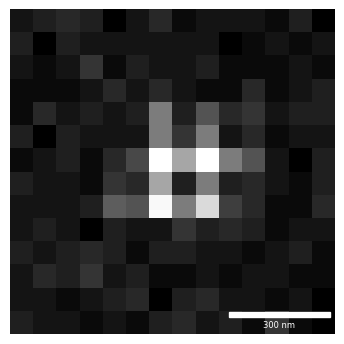

In [43]:
fig, axs = plotter.one_column_plot()

# --- left: raw Bayer image ---
vmax_bayer = np.percentile(bayer_image, 99.5)
axs = plotter.image_plot(axs, bayer_image[38:52,71:85], scalebar_color='white', scalebarsize=300, scalebar=True, scalebarlabel='300 nm')

folder='/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Conference Presentations/20260302_DurhamTalks/Research/fig/multicolour_camera/FRET/'
plt.savefig(os.path.join(folder, 'FRET_exemplar_image_single.svg'))
plt.show()
